<a href="https://colab.research.google.com/github/alimoorreza/DrakeUniversityCVRG_Fall26/blob/main/sam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [Segment Anything (SAM)](https://github.com/facebookresearch/segment-anything)

1.   [official link](https://github.com/facebookresearch/segment-anything)
2.   Others



# Automatically generating object masks with SAM

Since SAM can efficiently process prompts, masks for the entire image can be generated by sampling a large number of prompts over an image. This method was used to generate the dataset SA-1B.

The class `SamAutomaticMaskGenerator` implements this capability. It works by sampling single-point input prompts in a grid over the image, from each of which SAM can predict multiple masks. Then, masks are filtered for quality and deduplicated using non-maximal suppression. Additional options allow for further improvement of mask quality and quantity, such as running prediction on multiple crops of the image or postprocessing masks to remove small disconnected regions and holes.

## Environment Set-up

If running locally using jupyter, first install `segment_anything` in your environment using the [installation instructions](https://github.com/facebookresearch/segment-anything#installation) in the repository. If running from Google Colab, set `using_colab=True` below and run the cell. In Colab, be sure to select 'GPU' under 'Edit'->'Notebook Settings'->'Hardware accelerator'.

In [1]:
using_colab = True

In [2]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

    !mkdir images
    !wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg

    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA is available: True
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-ad6oessg
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-ad6oessg
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36634 sha256=92216272f6cf9f676e825741c957634b0395b4f7a02a7219bd455c5c452cfa7a
  Stored in directory: /tmp/pip-ephem-wheel-cache-1odqj492/wheels/5d/7b/4a/c7fda89f2e27647dd0816f51ea103992b1b6f0f53ad234895c
Successfully built segment_anything
--2026-09-18 17:11:52--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.co

## Set-up

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
import sys
import os
import pickle
sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor


def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    polygons = []
    color = []
    for ann in sorted_anns:
        m = ann['segmentation']
        img = np.ones((m.shape[0], m.shape[1], 3))
        color_mask = np.random.random((1, 3)).tolist()[0]
        for i in range(3):
            img[:,:,i] = color_mask[i]
        ax.imshow(np.dstack((img, m*0.35)))


sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type     = "vit_h"

device         = "cuda"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)


# To run automatic mask generation, provide a SAM model to the SamAutomaticMaskGenerator class.
# Set the path below to the SAM checkpoint. Running on CUDA and with the default model is recommended.
mask_generator_1  = SamAutomaticMaskGenerator(sam)

# There are several tunable parameters in automatic mask generation that control how densely points are
# sampled and what the thresholds are for removing low quality or duplicate masks. Additionally, generation
# can be automatically run on crops of the image to get improved performance on smaller objects, and
# post-processing can remove stray pixels and holes. Here is an example configuration that samples more masks:
mask_generator_2 = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,  # Requires open-cv to run post-processing
)


In [ ]:
root_dir            = "/content/drive/MyDrive/Colab Notebooks/research/reasoning_seg/images/"
file_names          = root_dir + 'image_names.txt'
file_imgs           = open(file_names, "r")
image_list          = file_imgs.readlines()
is_display_enabled  = False

dest_root_dir       = "/content/drive/MyDrive/Colab Notebooks/research/reasoning_seg/sam_outputs/"
if not os.path.exists(dest_root_dir):
  os.makedirs(dest_root_dir)

file_mask_params    = open(dest_root_dir + "mask_params_for_SAM.txt", "w")
sam_mask_params     = "points_per_side=32 \n" + \
                      "pred_iou_thresh=0.86 \n" + \
                      "stability_score_thresh=0.92 \n" + \
                      "crop_n_layers=1 \n" + \
                      "crop_n_points_downscale_factor=2 \n" + \
                      "min_mask_region_area=100,  # Requires open-cv to run post-processing \n"
file_mask_params.write(sam_mask_params)
file_mask_params.close()

for cur_image in image_list:

  cur_image   = cur_image.rstrip('\n')
  #image      = cv2.imread(root_dir + 'beaver/beaver0003.png')
  image       = cv2.imread(root_dir + cur_image)
  image       = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  #masks1     = mask_generator_1.generate(image)
  masks2      = mask_generator_2.generate(image)

  if is_display_enabled == True:
    plt.figure(figsize=(10,10))
    plt.imshow(image)
    show_anns(masks2)
    plt.axis('off')
    plt.show()


  # ---- save the mask ----

  # save the masks + image as pickle file
  f1      = open(dest_root_dir + cur_image[0:-4] + '.pkl', 'wb')
  my_dict = {'image': image, 'masks': masks2}
  pickle.dump(my_dict, f1)
  f1.close()


## Example image to generate and show different masks

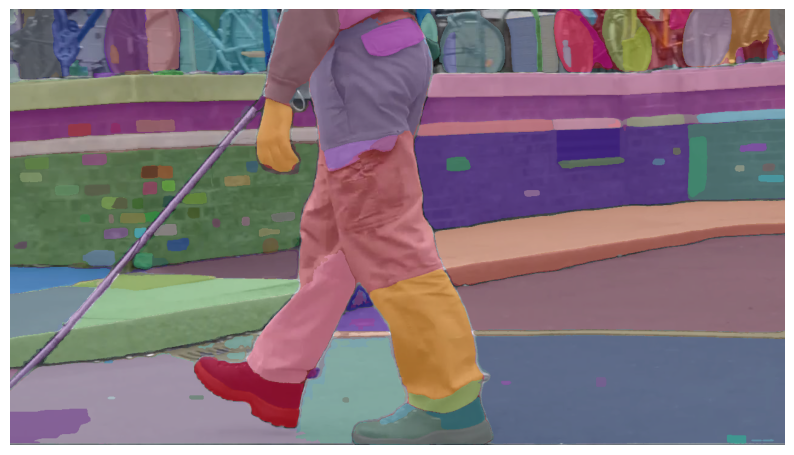

In [5]:
root_dir            = "/content/drive/MyDrive/Colab Notebooks/research/reasoning_seg/images/"
file_names          = root_dir + 'image_names.txt'
file_imgs           = open(file_names, "r")
image_list          = file_imgs.readlines()

image_list  = [image_list[0]]

for cur_image in image_list:

  cur_image = cur_image.rstrip('\n')
  image     = cv2.imread(root_dir + cur_image)
  image     = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  #masks1    = mask_generator_1.generate(image)
  masks2    = mask_generator_2.generate(image)


  plt.figure(figsize=(10,10))
  plt.imshow(image)
  show_anns(masks2)
  plt.axis('off')
  plt.show()

157
(720, 1280)


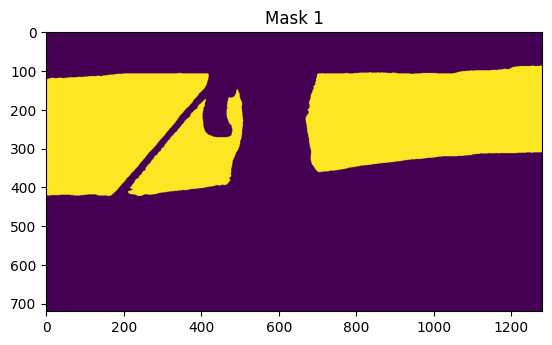

In [6]:
sorted_anns = sorted(masks2, key=(lambda x: x['area']), reverse=True)
#print(sorted_anns)
print(len(sorted_anns))
cur_ann = sorted_anns[0]
#print(cur_ann.keys()) # dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
print(cur_ann['segmentation'].shape)
plt.imshow(cur_ann['segmentation'])
plt.title('Mask 1')
plt.show()

(720, 1280)


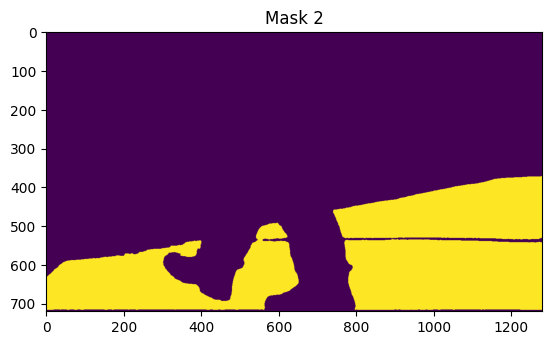

In [ ]:
cur_ann = sorted_anns[1]
#print(cur_ann.keys()) # dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
print(cur_ann['segmentation'].shape)
plt.imshow(cur_ann['segmentation'])
plt.title('Mask 2')
plt.show()

(720, 1280)


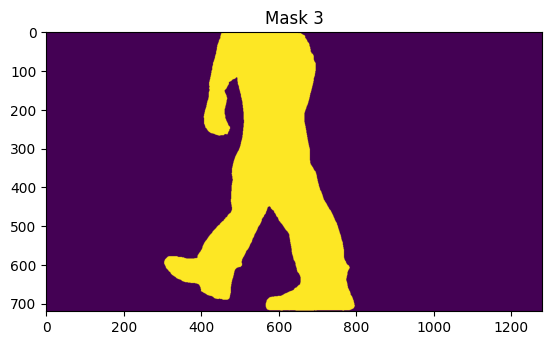

In [ ]:
cur_ann = sorted_anns[2]
#print(cur_ann.keys()) # dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
print(cur_ann['segmentation'].shape)
plt.imshow(cur_ann['segmentation'])
plt.title('Mask 3')
plt.show()

(720, 1280)


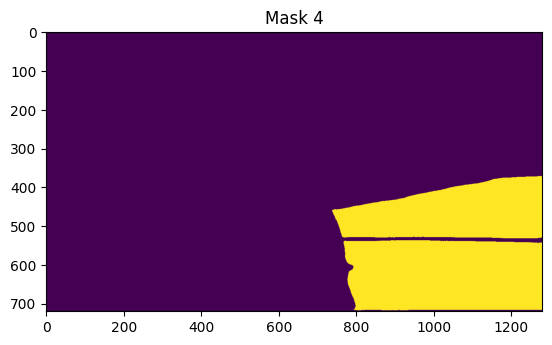

In [ ]:
cur_ann = sorted_anns[3]
#print(cur_ann.keys()) # dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
print(cur_ann['segmentation'].shape)
plt.imshow(cur_ann['segmentation'])
plt.title('Mask 4')
plt.show()

(720, 1280)


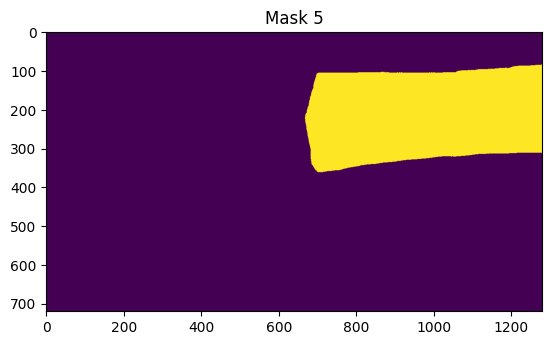

In [ ]:
cur_ann = sorted_anns[4]
#print(cur_ann.keys()) # dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
print(cur_ann['segmentation'].shape)
plt.imshow(cur_ann['segmentation'])
plt.title('Mask 5')
plt.show()

(720, 1280)


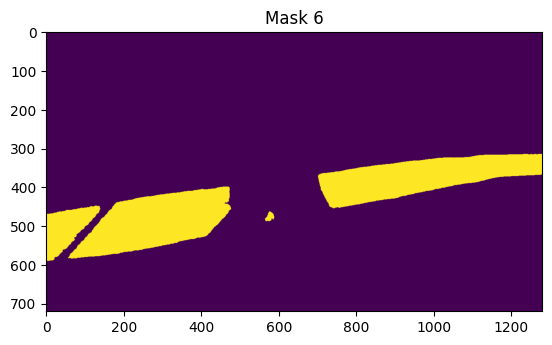

In [ ]:
cur_ann = sorted_anns[5]
#print(cur_ann.keys()) # dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
print(cur_ann['segmentation'].shape)
plt.imshow(cur_ann['segmentation'])
plt.title('Mask 6')
plt.show()

(720, 1280)


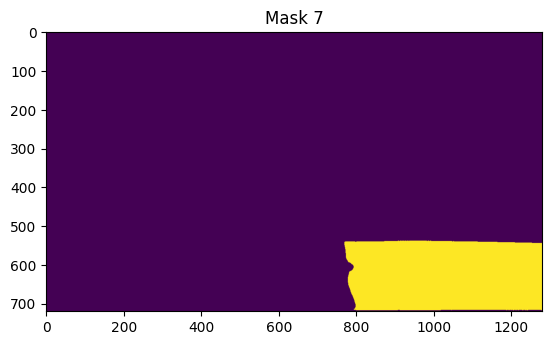

In [ ]:
cur_ann = sorted_anns[6]
#print(cur_ann.keys()) # dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
print(cur_ann['segmentation'].shape)
plt.imshow(cur_ann['segmentation'])
plt.title('Mask 7')
plt.show()

(720, 1280)


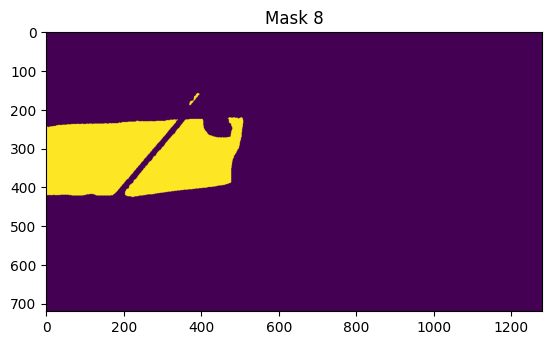

In [ ]:
cur_ann = sorted_anns[7]
#print(cur_ann.keys()) # dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
print(cur_ann['segmentation'].shape)
plt.imshow(cur_ann['segmentation'])
plt.title('Mask 8')
plt.show()

###**Generate prompt-based segmentation mask**
- Call `SamPredictor.predict()` with a text prompt corresponding to any sidewalk object of interest.

- You can either manually test the `predict()` method for individual objects or write a script to automatically generate masks for each object iteratively.